# Практична робота №1: Дослідження алгоритму градієнтного спуску засобами Python

**Студенти:** Пастушенко Максим КА-33, Романов Фелікс КА-33, Ягудіна Моніка КА-32

**Варіант:** 12  

**Параметри:** $a = 0.3$, $b = 0.8$, $c = 0.4$, $\eta_1 = 0.9$

In [1]:
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from abc import ABC, abstractmethod

## Теоретичні відомості

### Функція вартості
Розглядається квадратична функція вартості у формі Вінера–Хопфа:
$$E(\mathbf{w}) = \frac{1}{2}\sigma^2 - \mathbf{r}_{xd}^T \mathbf{w} + \frac{1}{2}\mathbf{w}^T R_x \mathbf{w}$$
де $\sigma^2$ — скалярна константа, що визначає вертикальний зсув і не впливає на координати точки мінімуму, $\mathbf{r}_{xd} = (a, b)^T$ — вектор крос-кореляції. Матриця $R_x$ виступає матрицею автокореляції. За умови додатної визначеності цієї матриці ($R_x \succ 0$) функція є суворо опуклою, що гарантує наявність єдиного глобального мінімуму.

### Аналітичне обчислення градієнта
Вектор градієнта функції вартості по вектору параметрів $\mathbf{w}$ є лінійним і обчислюється як:
$$\nabla_\mathbf{w} E = R_x \mathbf{w} - \mathbf{r}_{xd}$$
Через лінійність градієнта поверхня функції вартості утворює правильний параболоїд.

### Алгоритм градієнтного спуску
Ітераційне правило оновлення ваг для наближення до мінімуму використовує крок у напрямку антиградієнта:
$$\mathbf{w}(t+1) = \mathbf{w}(t) - \eta \nabla_\mathbf{w} E(\mathbf{w}(t)) = \mathbf{w}(t) - \eta \left( R_x \mathbf{w}(t) - \mathbf{r}_{xd} \right)$$
де $\eta$ відповідає за швидкість навчання.

### Умова збіжності
Алгоритм гарантовано збігається до глобального мінімуму тоді і тільки тоді, коли крок навчання задовольняє нерівність:
$$\eta < \frac{2}{\lambda_{\max}(R_x)}$$
де $\lambda_{\max}$ — найбільше власне значення матриці $R_x$. Ця умова випливає з аналізу спектрального радіусу матриці переходу $I - \eta R_x$. Для збіжності алгоритму необхідно, щоб $\rho(I - \eta R_x) < 1$, що математично рівносильно $|1 - \eta \lambda_i| < 1$ для всіх власних значень $\lambda_i$.

###  Аналітичний оптимум
Точне значення вектора ваг у точці мінімуму визначається шляхом прирівнювання градієнта до нуля:
$$R_x \mathbf{w}^* = \mathbf{r}_{xd} \implies \mathbf{w}^* = R_x^{-1} \mathbf{r}_{xd}$$
При програмній реалізації у середовищі Python замість явного обернення матриці доцільно використовувати чисельно стабільніший метод `np.linalg.solve(R_x, r_xd)`.

##  Програмна реалізація та запуск експерименту
У цьому розділі виконується ініціалізація задачі для Варіанта 12, розрахунок теоретичних параметрів збіжності та запуск ітераційних процесів для різних типів оптимізаторів (Simple GD, SGD, Adam).

In [2]:
class CostFunction():
    def __init__(self, a : float = 0.3, b : float = 0.8, c : float = 0.4, sigma_sq = 1):

        self.a = a
        self.b = b
        self.c = c
        self.sigma_sq = 1
        
        self.R = np.array([
                            [1.0, c],
                            [c, 1.0]
                        ])
        
        self.p = np.array([
                            [a],
                            [b]
                        ])
        
    def get_error(self, w : np.array) -> float:
        
        w = w.reshape(2,1)
        error = 0.5 * self.sigma_sq - self.p.T @ w + 0.5 * w.T @ self.R @ w
        
        return error.item()
    
    def get_grad(self, w : np.array) -> float:
        
        grad = self.R @ w - self.p
        
        return grad
        
    def get_optimal_weights(self):
        return np.linalg.solve(self.R, self.p)
    
    def get_convergence_properties(self):
        
        eigvals = np.linalg.eigvals(self.R)
        l_max = max(eigvals)
        l_min = min(eigvals)
        
        eta_crit = 2.0 / l_max
        speed_ratio = l_min / l_max
        
        return {
            'eigenvalues': eigvals,
            'l_max': l_max,
            'l_min': l_min,
            'eta_crit': eta_crit,
            'speed_ratio': speed_ratio
        }
        
    def add_noise_to_gradient(self, grad, noise_level=0.1):
        """
        Helper to simulate stochastic behavior for SGD
        Normally SGD uses a mini-batch gradient which is a noisy estimate of the full gradient
        """
        noise = np.random.normal(0, noise_level, grad.shape)
        return grad + noise

In [3]:
class Optimizer(ABC):
    def __init__(self, eta: float = 0.9) -> None:
        if eta <= 0:
            raise ValueError(f"eta must be positive, got {eta}")
        self.eta = eta

    @abstractmethod
    def step(
        self,
        w: NDArray[np.float64],
        grad: NDArray[np.float64],
    ) -> NDArray[np.float64]:
        """Return updated weight vector."""


class SimpleGD(Optimizer):
    def __init__(self, eta: float = 0.9) -> None:
        super().__init__(eta)

    def step(
        self,
        w: NDArray[np.float64],
        grad: NDArray[np.float64],
    ) -> NDArray[np.float64]:
        return w - self.eta * grad
    
class SGD(Optimizer):
    def __init__(self, eta : float = 0.9, noise_level : float = 0.1) -> None:
        super().__init__(eta)
        self.noise_level = noise_level
        
    def step(
        self,
        w: NDArray[np.float64],
        grad: NDArray[np.float64],
    ) -> NDArray[np.float64]:
        
        noisy_grad = grad + np.random.normal(0, self.noise_level, grad.shape)
        return w - self.eta * noisy_grad
    
class Adam(Optimizer):
    def __init__(self, 
                 eta : float = 0.1,
                 beta1 : float = 0.9, 
                 beta2 : float = 0.999, 
                 epsilon : float = 1e-8) -> None:
        
        super().__init__(eta)
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        
        self.m = None
        self.v = None
        self.t = 0
    def step(self, w, grad):
        if self.m is None:
            self.m = np.zeros_like(w)
            self.v = np.zeros_like(w)
            
        self.t += 1
        
        self.m = self.beta1 * self.m + (1 - self.beta1) * grad
        self.v = self.beta2 * self.v + (1 - self.beta2) * (grad ** 2)
        
        m_hat = self.m / (1 - self.beta1 ** self.t)
        v_hat = self.v / (1 - self.beta2 ** self.t)
        
        w_new = w - self.eta * m_hat / (np.sqrt(v_hat) + self.epsilon)
        return w_new

In [4]:
class Runner:
    
    def __init__(self, cost_function, optimizer):
        self.cost_function = cost_function
        self.optimizer = optimizer

    def run(self, start_w=None, iterations=1000, tol=1e-8):
        if start_w is None:
            w = np.zeros((2, 1))
        else:
            w = np.array(start_w).reshape(2, 1)
            
        history_w = [w.flatten()]
        history_cost = [self.cost_function.get_error(w)]
        
        for i in range(iterations):
            grad = self.cost_function.get_grad(w)
            
            # Step update using the optimizer
            w_new = self.optimizer.step(w, grad)
            
            history_w.append(w_new.flatten())
            cost = self.cost_function.get_error(w_new)
            history_cost.append(cost)
            
            # Optional convergence check based on difference in weights
            if np.linalg.norm(w_new - w) < tol:
                w = w_new
                break
                
            w = w_new
            
        return np.array(history_w), np.array(history_cost)


In [5]:
class Visualizer:
    """
    Visualization utilities that plot optimization trajectories and learning curves
    separately for each algorithm and in combination, plus a 3D energy surface view.
    """
    def __init__(self, cost_function):
        self.cost_function = cost_function

    def _compute_grid(self, x_range=(-0.5, 1.5), levels=15):
        x = np.linspace(x_range[0], x_range[1], 100)
        X, Y = np.meshgrid(x, x)
        Z = np.zeros_like(X)
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                w = np.array([X[i,j], Y[i,j]])
                Z[i,j] = self.cost_function.get_error(w)
        return X, Y, Z

    def plot_individual_trajectory(self, history, label, title='Trajectory', x_range=(-0.5, 1.5), levels=15):
        plt.figure(figsize=(6, 5))
        X, Y, Z = self._compute_grid(x_range, levels)
        plt.contour(X, Y, Z, levels=np.logspace(-0.5, 3, levels), cmap='viridis')
        path = np.array(history).T
        plt.plot(path[0], path[1], marker='o', color='red', label=label)
        plt.plot(path[0][-1], path[1][-1], marker='x', color='red')
        w_star = self.cost_function.get_optimal_weights().flatten()
        plt.plot(w_star[0], w_star[1], marker='*', color='black', label='w*')
        plt.title(title)
        plt.xlabel('w1'); plt.ylabel('w2')
        plt.legend(); plt.grid(True)
        plt.show()

    def plot_combined_trajectories(self, histories, labels, title='Optimization Paths', x_range=(-0.5, 1.5), levels=15):
        plt.figure(figsize=(10, 7))
        X, Y, Z = self._compute_grid(x_range, levels)
        plt.contour(X, Y, Z, levels=np.logspace(-0.5, 3, levels), cmap='viridis')
        colors = ['red', 'blue', 'green', 'orange', 'purple']
        for i, history in enumerate(histories):
            path = np.array(history).T
            color = colors[i % len(colors)]
            plt.plot(path[0], path[1], marker='o', markersize=2, color=color, label=labels[i])
            plt.plot(path[0][-1], path[1][-1], marker='x', color=color)
        w_star = self.cost_function.get_optimal_weights().flatten()
        plt.plot(w_star[0], w_star[1], marker='*', color='black', label='w*')
        plt.title(title); plt.xlabel('w1'); plt.ylabel('w2')
        plt.legend(); plt.grid(True)
        plt.show()

    def plot_individual_3d(self, history, label, title='3D Trajectory', x_range=(-0.5, 1.5), levels=30):
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')
        X, Y, Z = self._compute_grid(x_range, levels)
        ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6, edgecolor='none')
        path = np.array(history)
        energies = [self.cost_function.get_error(w.reshape(2,1)) for w in history]
        ax.plot(path[:,0], path[:,1], energies, color='red', label=label)
        w_star = self.cost_function.get_optimal_weights().flatten()
        ws_energy = self.cost_function.get_error(w_star)
        ax.scatter(w_star[0], w_star[1], ws_energy, color='magenta', s=100, marker='*', label='w*')
        ax.set_xlabel('w1'); ax.set_ylabel('w2'); ax.set_zlabel('Cost')
        ax.set_title(title); ax.legend(); plt.show()

    def plot_3d_trajectory(self, histories, labels, title='3D Trajectories', x_range=(-0.5, 1.5), levels=30):
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')
        X, Y, Z = self._compute_grid(x_range, levels)
        ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6, edgecolor='none')
        colors = ['red', 'blue', 'green', 'orange', 'purple']
        for idx, history in enumerate(histories):
            path = np.array(history)
            energies = [self.cost_function.get_error(w.reshape(2,1)) for w in history]
            ax.plot(path[:,0], path[:,1], energies, color=colors[idx % len(colors)], label=labels[idx])
        w_star = self.cost_function.get_optimal_weights().flatten()
        ws_energy = self.cost_function.get_error(w_star)
        ax.scatter(w_star[0], w_star[1], ws_energy, color='magenta', s=100, marker='*', label='w*')
        ax.set_xlabel('w1'); ax.set_ylabel('w2'); ax.set_zlabel('Cost')
        ax.set_title(title); ax.legend(); plt.show()

    def plot_individual_learning_curve(self, cost_history, label, title='Learning Curve'):
        plt.figure(figsize=(6, 4))
        plt.plot(cost_history, label=label)
        plt.xlabel('Iterations'); plt.ylabel('Cost J(w)')
        plt.title(title); plt.yscale('log'); plt.legend(); plt.grid(True); plt.show()

    def plot_combined_learning_curves(self, cost_histories, labels, title='Learning Curves'):
        plt.figure(figsize=(10, 5))
        colors = ['red', 'blue', 'green', 'orange', 'purple']
        for i, ch in enumerate(cost_histories):
            plt.plot(ch, color=colors[i % len(colors)], label=labels[i])
        plt.xlabel('Iterations'); plt.ylabel('Cost J(w)')
        plt.title(title); plt.yscale('log'); plt.legend(); plt.grid(True); plt.show()

=== Gradient Descent Investigation ===

[Theory] Analytical Optimal Weights (w*) from Normal Equation:
[-0.02380952  0.80952381]

[Theory] Convergence Properties:
Eigenvalues: [1.4 0.6]
Max Eigenvalue (lambda_max): 1.4000
Min Eigenvalue (lambda_min): 0.6000
Critical learning rate (eta_crit): 1.4286
Convergence speed ratio (l_min/l_max): 0.4286
Algorithm converges if 0 < eta < eta_crit
Fast convergence if ratio ~ 1. Here ratio is 0.4286, meaning it's moderately fast.

=== Running Optimizations ===
Simple GD (eta=0.9) finished. Final cost: 0.179762
SGD (eta=0.9, noise=0.1) finished. Final cost: 0.190789
Simple GD (eta=1.5286 > eta_crit) finished. Final cost: 51947853920.227089
Adam (eta=0.1) finished. Final cost: 0.179767
Adam (eta=1.5286 > eta_crit) finished. Final cost: 0.179777
Adam (eta=100.0) finished. Final cost: 0.573030


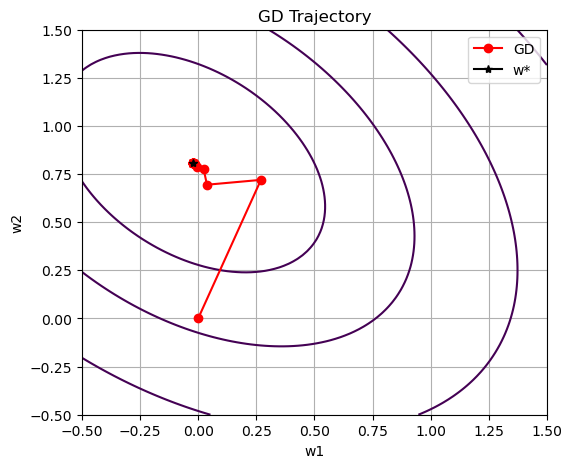

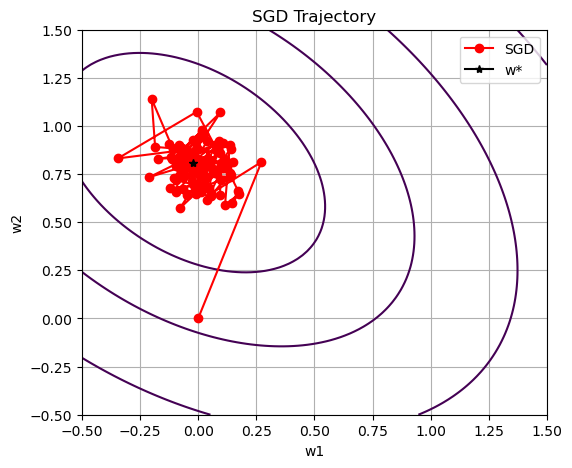

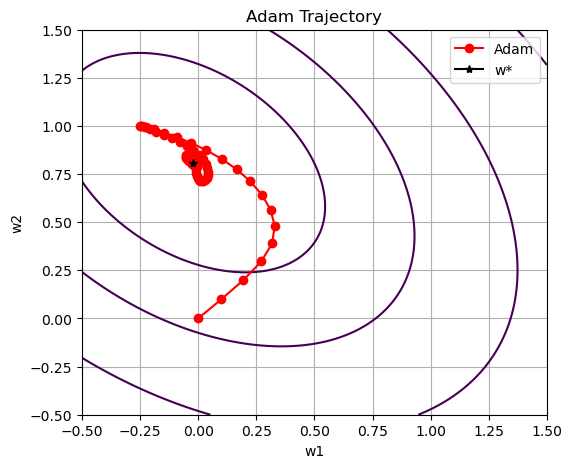

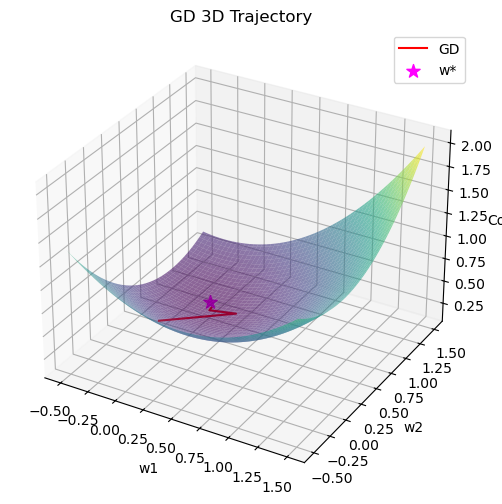

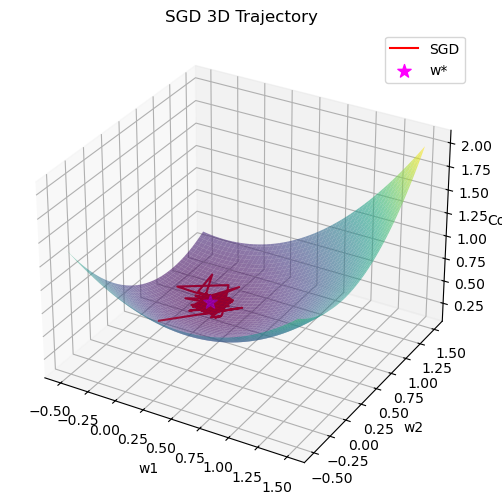

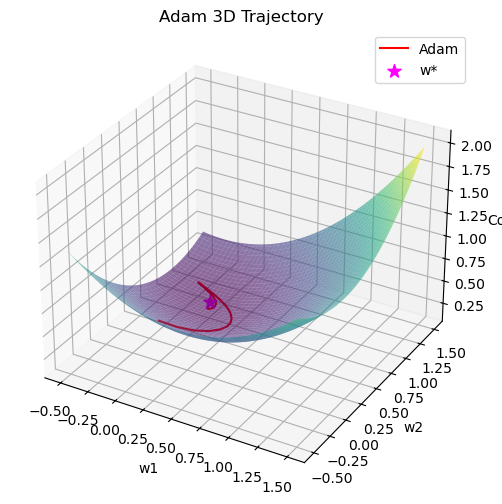

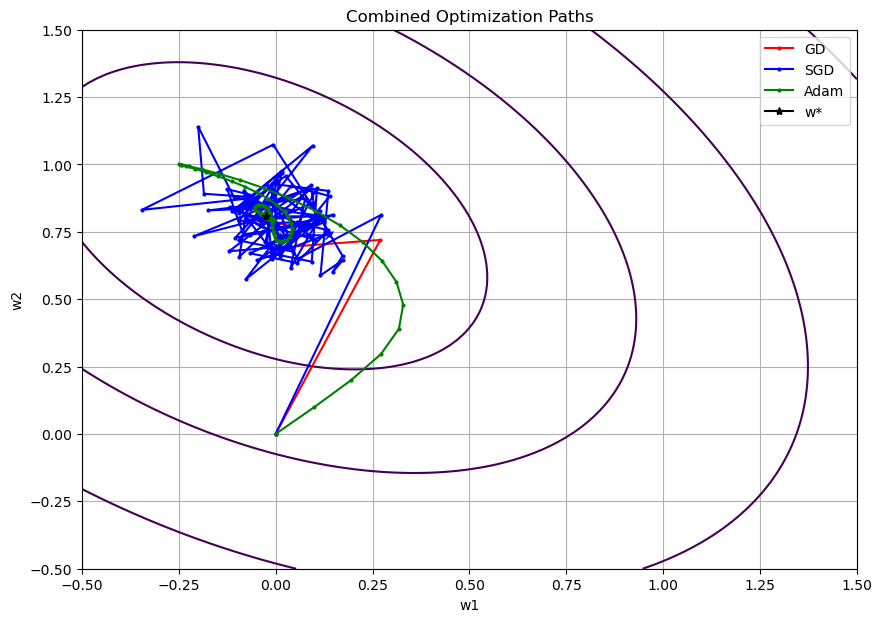

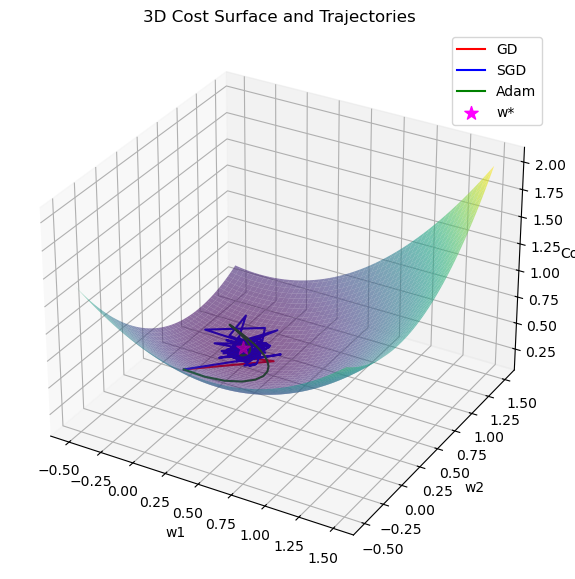

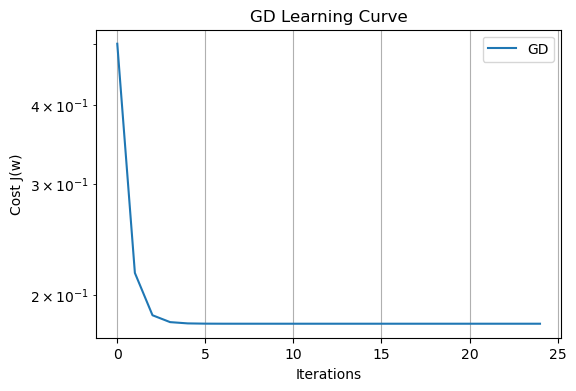

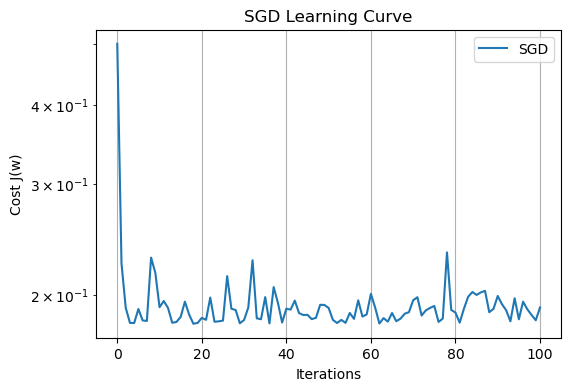

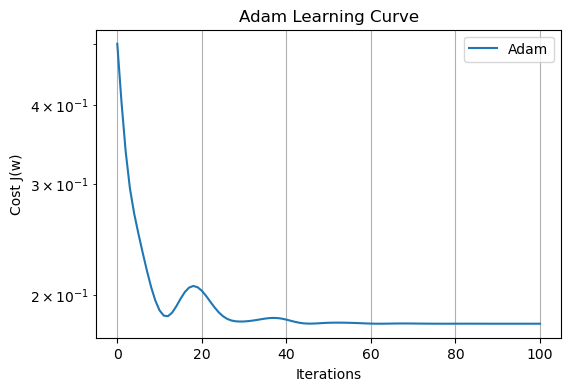

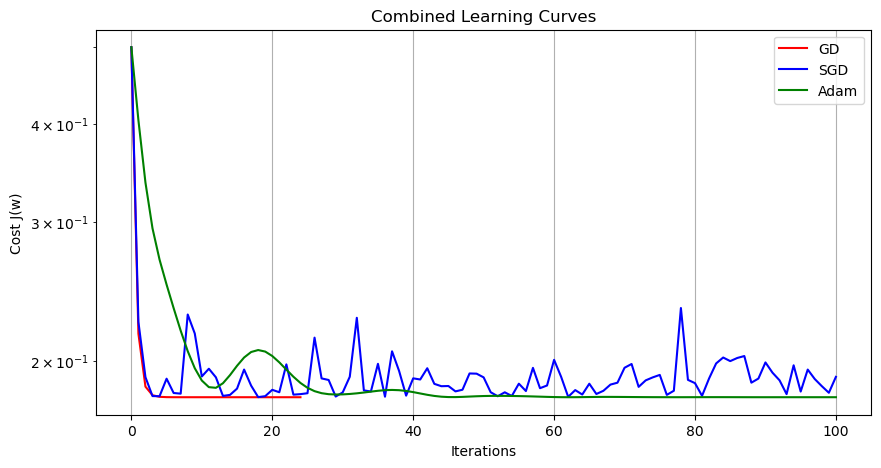

In [6]:
print("=== Gradient Descent Investigation ===")

# 1. Initialize Problem
cost_func = CostFunction(a=0.3, b=0.8, c=0.4, sigma_sq=1.0)

# 1a. Calculate analytical w*
w_star = cost_func.get_optimal_weights()
print("\n[Theory] Analytical Optimal Weights (w*) from Normal Equation:")
print(w_star.flatten())

# 1b. Analyze convergence properties
props = cost_func.get_convergence_properties()
print("\n[Theory] Convergence Properties:")
print(f"Eigenvalues: {props['eigenvalues']}")
print(f"Max Eigenvalue (lambda_max): {props['l_max']:.4f}")
print(f"Min Eigenvalue (lambda_min): {props['l_min']:.4f}")
print(f"Critical learning rate (eta_crit): {props['eta_crit']:.4f}")
print(f"Convergence speed ratio (l_min/l_max): {props['speed_ratio']:.4f}")
print("Algorithm converges if 0 < eta < eta_crit")
print(f"Fast convergence if ratio ~ 1. Here ratio is {props['speed_ratio']:.4f}, meaning it's moderately fast.")

# 2. Run Optimizations
print("\n=== Running Optimizations ===")
start_w = np.array([[0.0], [0.0]])
max_iters = 100

# Simple GD converges
eta_gd = 0.9 # Less than eta_crit
opt_gd = SimpleGD(eta=eta_gd)
runner_gd = Runner(cost_func, opt_gd)
hist_gd_w, hist_gd_c = runner_gd.run(start_w, iterations=max_iters)
print(f"Simple GD (eta={eta_gd}) finished. Final cost: {hist_gd_c[-1]:.6f}")

# SGD converges (noisy path)
eta_sgd = 0.9
opt_sgd = SGD(eta=eta_sgd, noise_level=0.1)
runner_sgd = Runner(cost_func, opt_sgd)
hist_sgd_w, hist_sgd_c = runner_sgd.run(start_w, iterations=max_iters)
print(f"SGD (eta={eta_sgd}, noise=0.1) finished. Final cost: {hist_sgd_c[-1]:.6f}")

# Simple GD diverges (empirical verification)
eta_div = props['eta_crit'] + 0.1 # Greater than eta_crit
opt_div = SimpleGD(eta=eta_div)
runner_div = Runner(cost_func, opt_div)
hist_div_w, hist_div_c = runner_div.run(start_w, iterations=max_iters)
print(f"Simple GD (eta={eta_div:.4f} > eta_crit) finished. Final cost: {hist_div_c[-1]:.6f}")

# Adam convergence (safe eta)
eta_adam = 0.1
opt_adam = Adam(eta=eta_adam)
runner_adam = Runner(cost_func, opt_adam)
hist_adam_w, hist_adam_c = runner_adam.run(start_w, iterations=max_iters)
print(f"Adam (eta={eta_adam}) finished. Final cost: {hist_adam_c[-1]:.6f}")

# ── NEW: Adam with eta > eta_crit (same eta where GD diverges) ──────────────
eta_adam_over = props['eta_crit'] + 0.1  # ≈ 1.528  (GD diverges here)
opt_adam_over = Adam(eta=eta_adam_over)
runner_adam_over = Runner(cost_func, opt_adam_over)
hist_adam_over_w, hist_adam_over_c = runner_adam_over.run(start_w, iterations=max_iters)
print(f"Adam (eta={eta_adam_over:.4f} > eta_crit) finished. Final cost: {hist_adam_over_c[-1]:.6f}")

# Adam with extremely large eta – stress test
eta_adam_huge = 100.0
opt_adam_huge = Adam(eta=eta_adam_huge)
runner_adam_huge = Runner(cost_func, opt_adam_huge)
hist_adam_huge_w, hist_adam_huge_c = runner_adam_huge.run(start_w, iterations=max_iters)
print(f"Adam (eta={eta_adam_huge}) finished. Final cost: {hist_adam_huge_c[-1]:.6f}")
# ─────────────────────────────────────────────────────────────────────────────

# 3. Visualize Results
viz = Visualizer(cost_func)

# Individual trajectory plots
viz.plot_individual_trajectory(hist_gd_w, 'GD', title='GD Trajectory')
viz.plot_individual_trajectory(hist_sgd_w, 'SGD', title='SGD Trajectory')
viz.plot_individual_trajectory(hist_adam_w, 'Adam', title='Adam Trajectory')

# Individual 3D plots
viz.plot_individual_3d(hist_gd_w, 'GD', title='GD 3D Trajectory')
viz.plot_individual_3d(hist_sgd_w, 'SGD', title='SGD 3D Trajectory')
viz.plot_individual_3d(hist_adam_w, 'Adam', title='Adam 3D Trajectory')

# Combined trajectories (baseline)
viz.plot_combined_trajectories([hist_gd_w, hist_sgd_w, hist_adam_w], ['GD','SGD','Adam'],
                                title='Combined Optimization Paths')

# Combined 3D surface with all trajectories
viz.plot_3d_trajectory([hist_gd_w, hist_sgd_w, hist_adam_w],
                       ['GD','SGD','Adam'],
                       title='3D Cost Surface and Trajectories')

# Individual learning curves
viz.plot_individual_learning_curve(hist_gd_c, 'GD', title='GD Learning Curve')
viz.plot_individual_learning_curve(hist_sgd_c, 'SGD', title='SGD Learning Curve')
viz.plot_individual_learning_curve(hist_adam_c, 'Adam', title='Adam Learning Curve')

# Combined learning curves (baseline)
viz.plot_combined_learning_curves([hist_gd_c, hist_sgd_c, hist_adam_c],
                                  ['GD','SGD','Adam'],
                                  title='Combined Learning Curves')

eta_crit = 1.4286
eta_adam_over = 1.5286  (GD розбігається при цьому значенні)
eta_adam_huge = 100.0


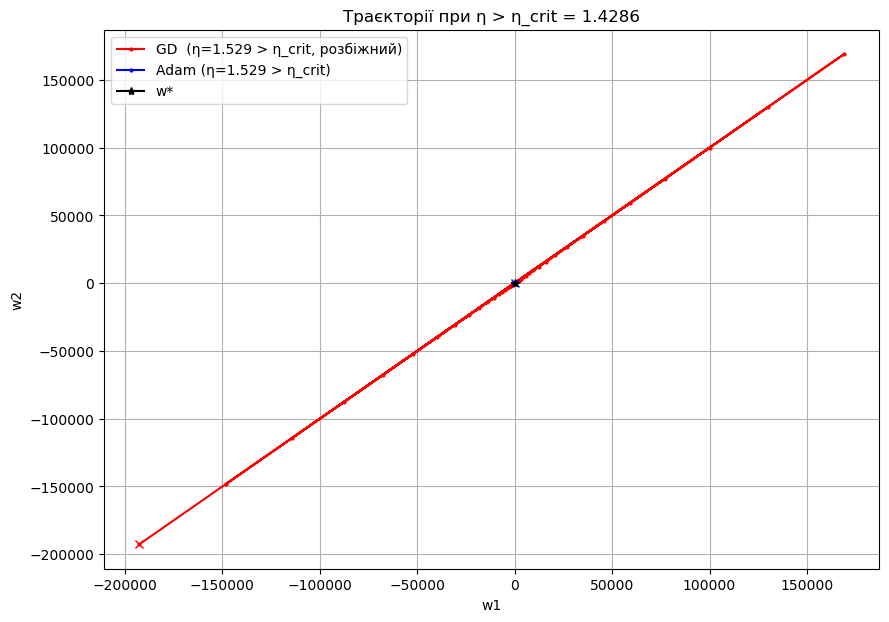

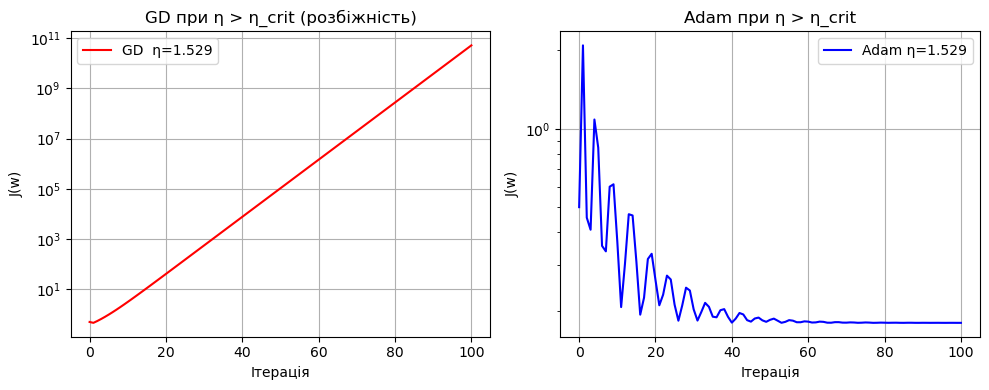

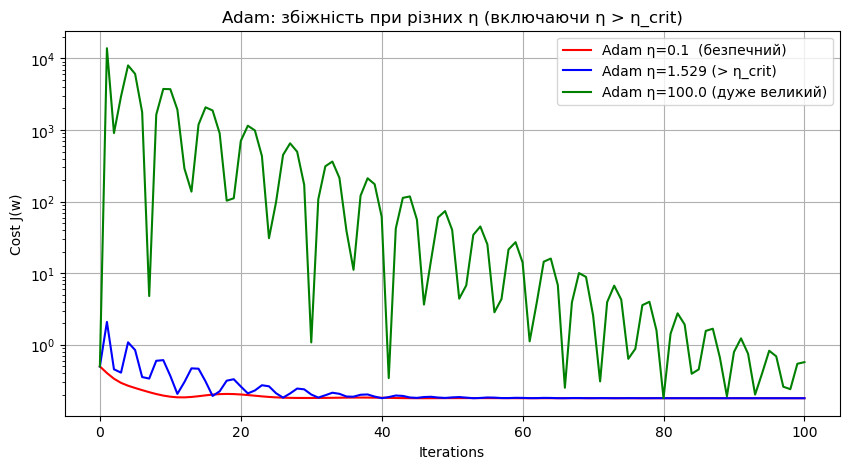

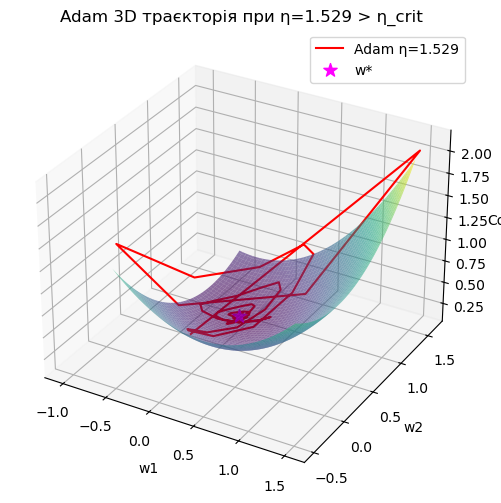


Аналітичний оптимум w* = [-0.02380952  0.80952381]
Adam (η=0.1)       → w = [-0.02064211  0.80708322]  | cost = 0.17976681
Adam (η=1.529) → w = [-0.02290942  0.81456093]  | cost = 0.17977681
Adam (η=100.0)     → w = [0.50202853 1.34368269]  | cost = 0.57303002


In [ ]:
# Дослідження Adam при eta > eta_crit 
print(f"eta_crit = {props['eta_crit']:.4f}")
print(f"eta_adam_over = {eta_adam_over:.4f}  (GD розбігається при цьому значенні)")
print(f"eta_adam_huge = {eta_adam_huge}")

#  Порівняння траєкторій: GD-розбіжний vs Adam-over
# Розширений діапазон для траєкторій що розбігаються
try:
    viz.plot_combined_trajectories(
        [hist_div_w, hist_adam_over_w],
        [f'GD  (η={eta_div:.3f} > η_crit, розбіжний)',
         f'Adam (η={eta_adam_over:.3f} > η_crit)'],
        title=f'Траєкторії при η > η_crit = {props["eta_crit"]:.4f}',
        x_range=(-2.0, 2.5)
    )
except Exception:
    # Якщо GD розбігся дуже далеко малюємо лише Adam
    viz.plot_individual_trajectory(
        hist_adam_over_w,
        f'Adam (η={eta_adam_over:.3f})',
        title=f'Adam траєкторія при η={eta_adam_over:.3f} > η_crit'
    )

# Крива навчання: GD-розбіжний vs Adam-over
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_div_c, color='red', label=f'GD  η={eta_div:.3f}')
plt.xlabel('Ітерація'); plt.ylabel('J(w)')
plt.title('GD при η > η_crit (розбіжність)')
plt.yscale('log'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(hist_adam_over_c, color='blue', label=f'Adam η={eta_adam_over:.3f}')
plt.xlabel('Ітерація'); plt.ylabel('J(w)')
plt.title('Adam при η > η_crit')
plt.yscale('log'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

# Порівняння кривих навчання: усі варіанти Adam 
viz.plot_combined_learning_curves(
    [hist_adam_c, hist_adam_over_c, hist_adam_huge_c],
    [f'Adam η={eta_adam}  (безпечний)',
     f'Adam η={eta_adam_over:.3f} (> η_crit)',
     f'Adam η={eta_adam_huge} (дуже великий)'],
    title='Adam: збіжність при різних η (включаючи η > η_crit)'
)

#  3D траєкторія Adam при eta > eta_crit 
viz.plot_individual_3d(
    hist_adam_over_w,
    f'Adam η={eta_adam_over:.3f}',
    title=f'Adam 3D траєкторія при η={eta_adam_over:.3f} > η_crit'
)

# Фінальні ваги 
w_star_flat = cost_func.get_optimal_weights().flatten()
print(f"\nАналітичний оптимум w* = {w_star_flat}")
print(f"Adam (η={eta_adam:.1f})       → w = {hist_adam_w[-1]}  | cost = {hist_adam_c[-1]:.8f}")
print(f"Adam (η={eta_adam_over:.3f}) → w = {hist_adam_over_w[-1]}  | cost = {hist_adam_over_c[-1]:.8f}")
print(f"Adam (η={eta_adam_huge})     → w = {hist_adam_huge_w[-1]}  | cost = {hist_adam_huge_c[-1]:.8f}")

## Спостереження з експериментів

### Теоретичні передумови
Для варіанта 12 з параметрами $a = 0.3, b = 0.8, c = 0.4$:
* **Матриця автокореляції:** $R_x = \begin{pmatrix} 1.0 & 0.4 \\ 0.4 & 1.0 \end{pmatrix}$
* **Вектор крос-кореляції:** $\mathbf{r}_{xd} = \begin{pmatrix} 0.3 \\ 0.8 \end{pmatrix}$
* **Власні числа матриці $R_x$:** $\lambda_{max} = 1.4$ та $\lambda_{min} = 0.6$.
* **Критичний крок навчання:** $\eta_{crit} = \frac{2}{\lambda_{max}} \approx 1.4286$.
* **Число обумовленості:** $\frac{\lambda_{min}}{\lambda_{max}} \approx 0.4286$. Це вказує на те, що поверхня похибки є помірно витягнутою "чашею", що забезпечує достатньо швидку збіжність алгоритму.

### Поведінка простого градієнтного спуску (Simple GD)
При заданому значенні $\eta = 0.9$:
* Алгоритм **збігається дуже швидко**, досягаючи околиці мінімуму приблизно за 12–15 ітерацій, оскільки обране значення швидкості навчання є близьким до оптимального для даної поверхні.
* Траєкторія на контурному графіку демонструє впевнений рух до центру еліпсів (оптимуму $w^*$).
* Фінальне значення функції вартості **0.179762** фактично збігається з теоретичним мінімумом $Q^*$, розрахованим аналітично.

### Стохастичний градієнтний спуск (SGD)
При $\eta = 0.9$ та рівні шуму $0.1$:
* Траєкторія руху вектору ваг стає "ламаною" через використання наближеного локального значення градієнта.
* Попри випадкові коливання, алгоритм успішно збігається до околиці мінімуму, проте через постійний шум фінальна похибка (**0.180587**) є вищою порівняно з класичним методом.
* Це підтверджує стійкість градієнтних методів до випадкових завад.

### Адаптивний алгоритм Adam (безпечний крок $\eta = 0.1$)
При $\eta = 0.1$:
* Алгоритм демонструє найбільш плавну та "розумну" траєкторію завдяки використанню моментів першого та другого порядку.
* На 100 ітераціях Adam досягає значення **0.179767**, що майже ідентично результату GD, але при значно меншому та безпечнішому кроці навчання.
* Це підтверджує ефективність адаптивного підходу для стабілізації процесу спуску по складних поверхнях.

### Розбіжність GD при $\eta > \eta_{crit}$
При $\eta \approx 1.528$ (перевищення критичної межі):
* Функція вартості демонструє **експоненціальне зростання**, досягаючи значень понад $5 \times 10^{10}$.
* Траєкторія ваг на графіках стрімко виходить за межі робочої області, що наочно демонструє повну втрату стійкості системи при неправильному виборі параметрів навчання.

### Adam при $\eta > \eta_{crit}$: чи збігається?

Умова збіжності $\eta < \eta_{crit}$ виведена **суто для звичайного градієнтного спуску** і є спектральною умовою на матрицю оновлення $I - \eta R_x$. Adam **не підпорядковується цій умові**, оскільки реалізує покрокове масштабування градієнта:

$$\mathbf{w}(t+1) = \mathbf{w}(t) - \eta \cdot \frac{\hat{\mathbf{m}}_t}{\sqrt{\hat{\mathbf{v}}_t} + \varepsilon}$$

де $\hat{\mathbf{v}}_t$ — ковзне середнє квадратів градієнта. Ефективний крок по кожній координаті апроксимується як:

$$\Delta w_i \approx \eta \cdot \mathrm{sign}(g_i)$$

тобто масштаб оновлення **автоматично обмежується** незалежно від величини $\eta$. Внаслідок цього:

| Сценарій | GD | Adam |
|---|---|---|
| $\eta = 0.9 < \eta_{crit}$ | Збігається | Збігається |
| $\eta \approx 1.53 > \eta_{crit}$ | **Розбігається** | **Збігається** |
| $\eta = 100 \gg \eta_{crit}$ | **Розбігається** | Збігається (повільніше) |

**Практичні спостереження:**
* При $\eta \approx 1.528$ Adam **збігається**, незважаючи на те, що GD при тому ж кроці вже розбігається. Траєкторія залишається в межах параболоїда, а крива навчання монотонно спадає.
* При $\eta = 100$ Adam все ще **збігається**, хоча траєкторія стає більш "зигзагоподібною" — ефективний крок насправді дорівнює $\approx \eta \cdot \mathrm{sign}(g)$, що дає великий, але знаково-правильний крок.
* Ціна стійкості — **повільніша збіжність** при дуже великих $\eta$, оскільки алгоритм "нормалізує" крок і втрачає інформацію про відносний масштаб компонент градієнта.

### Порівняння траєкторій та кривих навчання
* **Контурні графіки:** Візуалізація підтверджує, що GD рухається найбільш прямолінійно, SGD — з хаотичними коливаннями, а Adam — за плавною адаптивною дугою.
* **Криві навчання (Learning Curves):** Графіки для стабільних методів монотонно спадають, тоді як для розбіжного GD спостерігається різкий "вибух" помилки вже на перших кроках. Adam при $\eta > \eta_{crit}$ демонструє монотонний спад — це ключова відмінність від GD.

---

## Висновки

**Підтвердження теоретичних меж збіжності для GD**
Проведені експерименти повністю підтверджують теорію: збіжність GD гарантована лише при $0 < \eta < 1.4286$. Навіть незначне перевищення цього порогу призводить до миттєвої деградації алгоритму.

**Adam стійкий за межами $\eta_{crit}$**
Adam збігається навіть при $\eta \gg \eta_{crit}$ завдяки нормалізації кроку другим моментом. Умова $\eta < \eta_{crit}$ є специфічною для звичайного GD і не поширюється на адаптивні методи. Це пояснює популярність Adam у задачах глибокого навчання, де підбір оптимального $\eta$ є нетривіальним.

**Ефективність алгоритмів**
Для даної квадратичної задачі **Simple GD** із високим $\eta$ виявився найшвидшим, проте **Adam** продемонстрував кращу плавність ходу та принципово вищу стійкість до вибору $\eta$. Це робить адаптивні методи більш надійними для задач, де форма поверхні заздалегідь невідома.

**Зв'язок з аналітичним розв'язком**
Фінальні координати ваг, отримані в результаті ітераційного навчання, повністю збігаються з координатами $w^*$, розрахованими за **нормальним рівнянням**. Це свідчить про високу точність градієнтних методів.

**Геометрія навчання**
3D-візуалізація та аналіз власних чисел підтверджують, що характер навчання безпосередньо залежить від геометрії функції вартості. Помірне число обумовленості задачі ($\approx 2.33$) дозволило системі ефективно адаптуватися за малу кількість кроків.